In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np



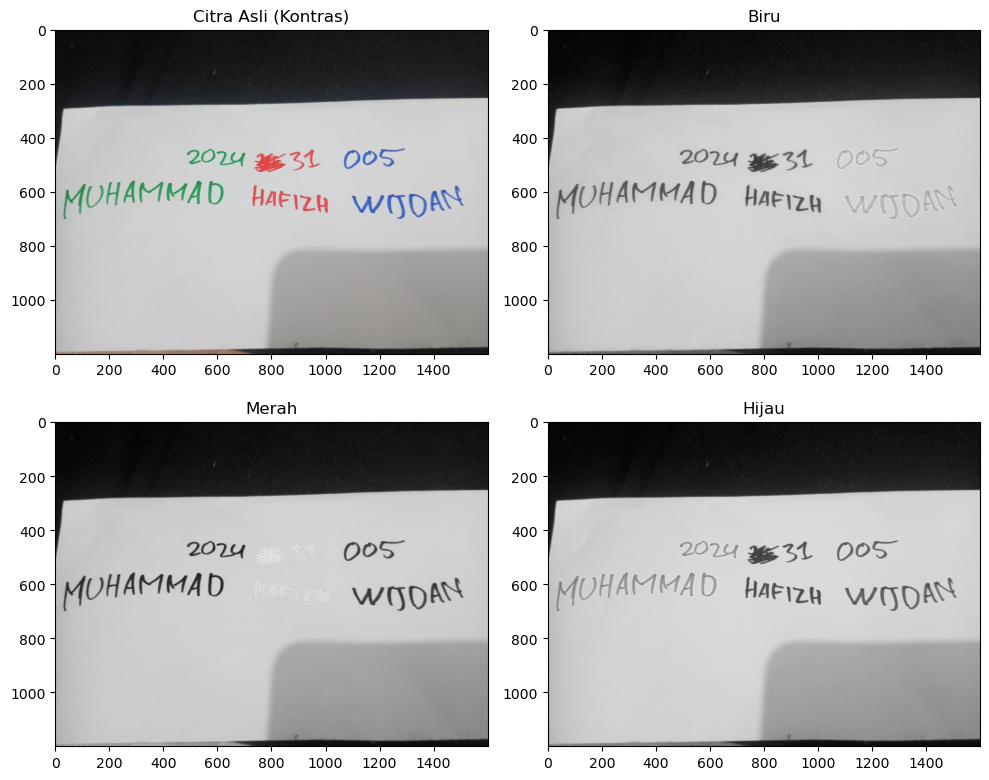

In [2]:
# Membaca Citra dan Pemisahan Kanal Warna 

# Baca citra (Pastikan file image_559780.png ada di folder yang sama)
img_bgr = cv2.imread("Muhammad Hafizh Wijdan_202431005.jpg")

# Konversi format BGR menjadi RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Ekstraksi masing-masing kanal warna
R = img_rgb[:, :, 0] # Kanal Merah
G = img_rgb[:, :, 1] # Kanal Hijau
B = img_rgb[:, :, 2] # Kanal Biru

# Menampilkan hasil
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs[0, 0].imshow(img_rgb)
axs[0, 0].set_title('Citra Asli (Kontras)')
axs[0, 1].imshow(B, cmap='gray')
axs[0, 1].set_title('Biru')
axs[1, 0].imshow(R, cmap='gray')
axs[1, 0].set_title('Merah')
axs[1, 1].imshow(G, cmap='gray')
axs[1, 1].set_title('Hijau')

plt.tight_layout()
plt.show()


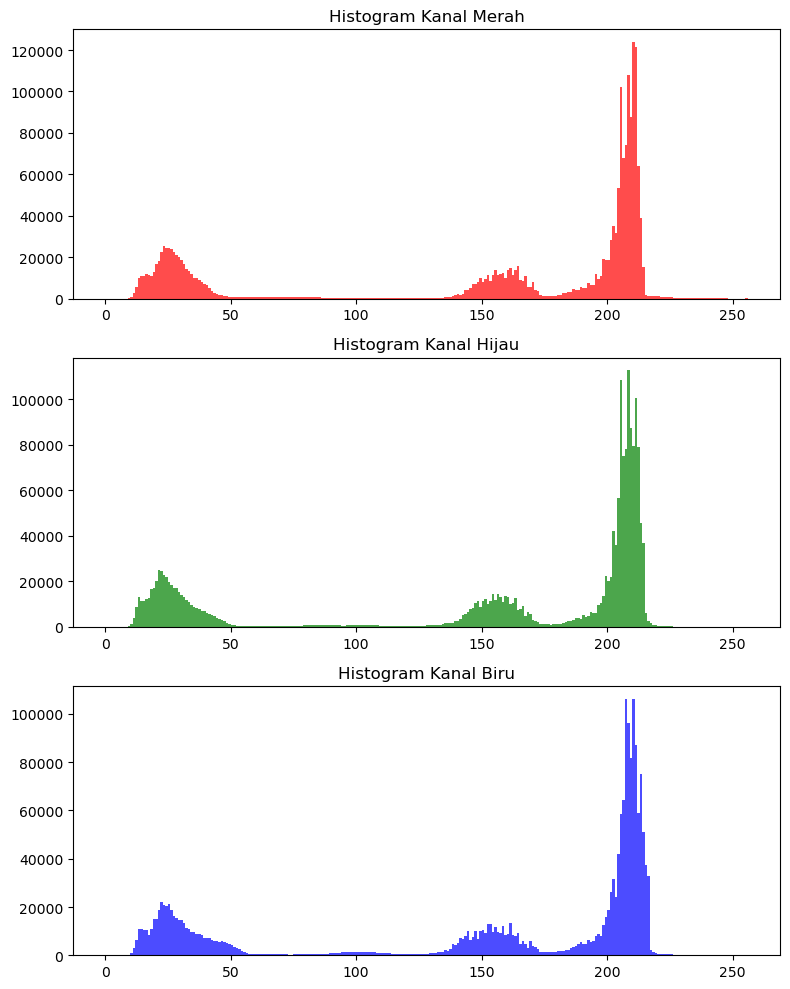

In [3]:
# Analisis Histogram 

fig_hist, axs_hist = plt.subplots(3, 1, figsize=(8, 10))

axs_hist[0].hist(R.ravel(), bins=256, range=[0, 256], color='red', alpha=0.7)
axs_hist[0].set_title('Histogram Kanal Merah')
axs_hist[1].hist(G.ravel(), bins=256, range=[0, 256], color='green', alpha=0.7)
axs_hist[1].set_title('Histogram Kanal Hijau')
axs_hist[2].hist(B.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.7)
axs_hist[2].set_title('Histogram Kanal Biru')

plt.tight_layout()
plt.show()




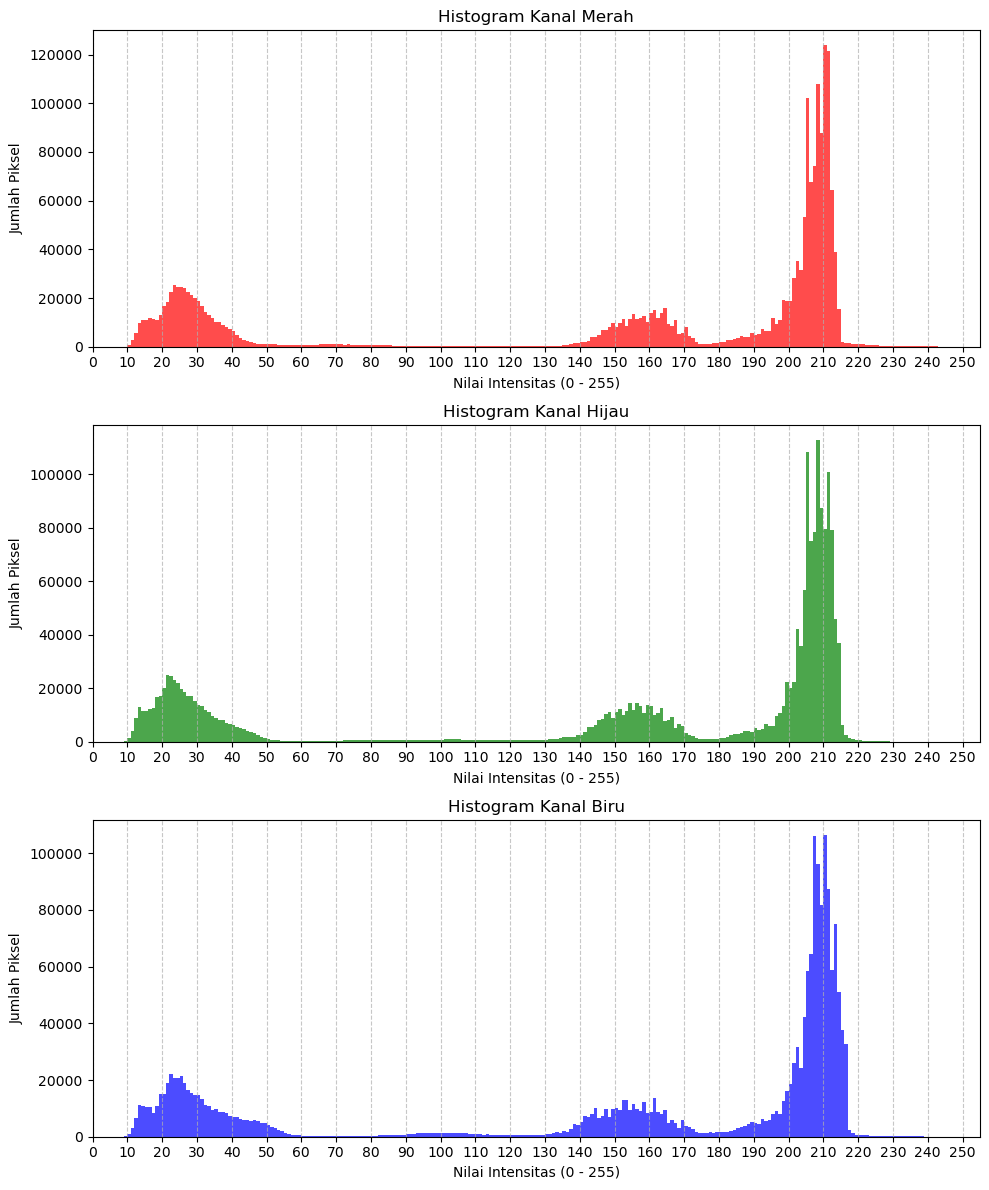

In [4]:
# Analisis Histogram 
fig_hist, axs_hist = plt.subplots(3, 1, figsize=(10, 12))

# 1. Histogram Merah
axs_hist[0].hist(R.ravel(), bins=256, range=[0, 256], color='red', alpha=0.7)
axs_hist[0].set_title('Histogram Kanal Merah')

# 2. Histogram Hijau
axs_hist[1].hist(G.ravel(), bins=256, range=[0, 256], color='green', alpha=0.7)
axs_hist[1].set_title('Histogram Kanal Hijau')

# 3. Histogram Biru
axs_hist[2].hist(B.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.7)
axs_hist[2].set_title('Histogram Kanal Biru')


for ax in axs_hist:
    ax.set_xlim([0, 255])
    # angka di bawah (sumbu X) muncul setiap kelipatan 10 
    ax.set_xticks(np.arange(0, 260, 10)) 
    # garis bantu putus-putus
    ax.grid(axis='x', linestyle='--', alpha=0.7) 
    ax.set_xlabel('Nilai Intensitas (0 - 255)')
    ax.set_ylabel('Jumlah Piksel')

plt.tight_layout()
plt.show()

Nilai Threshold OTSU:
- Kanal Merah : 112.0
- Kanal Hijau : 112.0
- Kanal Biru  : 114.0


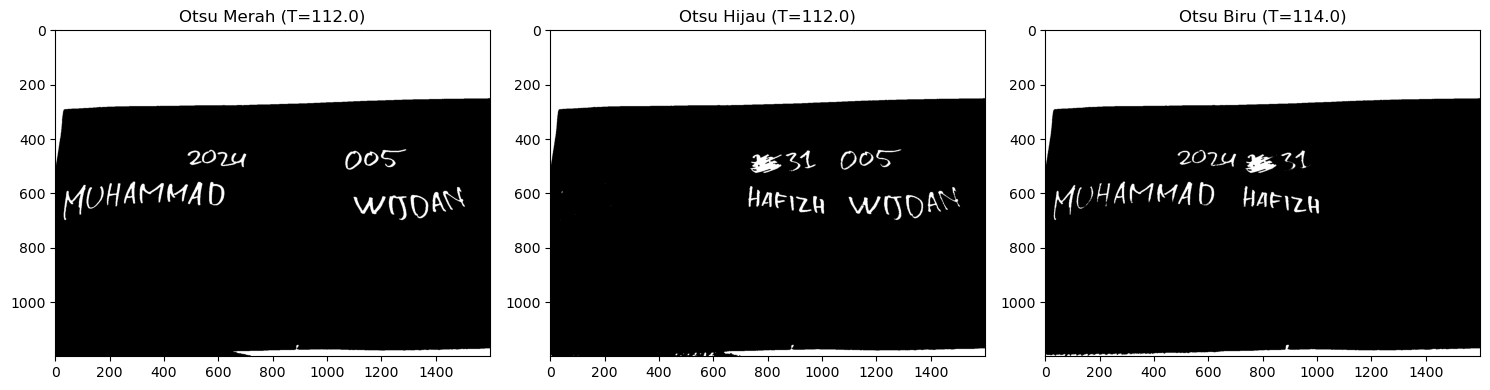

In [5]:

# Thresholding METODE OTSU (Otomatis)


# Perhitungan Otsu
ret_R_otsu, thresh_R_otsu = cv2.threshold(R, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
ret_G_otsu, thresh_G_otsu = cv2.threshold(G, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
ret_B_otsu, thresh_B_otsu = cv2.threshold(B, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

print(f"Nilai Threshold OTSU:")
print(f"- Kanal Merah : {ret_R_otsu}")
print(f"- Kanal Hijau : {ret_G_otsu}")
print(f"- Kanal Biru  : {ret_B_otsu}")

# Menampilkan hasil Otsu berjejer ke samping (dalam 1 Cell)
fig_otsu, axs_otsu = plt.subplots(1, 3, figsize=(15, 5))

axs_otsu[0].imshow(thresh_R_otsu, cmap='gray')
axs_otsu[0].set_title(f'Otsu Merah (T={ret_R_otsu})')

axs_otsu[1].imshow(thresh_G_otsu, cmap='gray')
axs_otsu[1].set_title(f'Otsu Hijau (T={ret_G_otsu})')

axs_otsu[2].imshow(thresh_B_otsu, cmap='gray')
axs_otsu[2].set_title(f'Otsu Biru (T={ret_B_otsu})')

plt.tight_layout()
plt.show()




Sedang memproses piksel dengan IF-ELSE (mungkin butuh beberapa detik)...
Selesai! Nilai Threshold (Fmin+Fmax)/2:
- Kanal Merah : 131
- Kanal Hijau : 127
- Kanal Biru  : 131


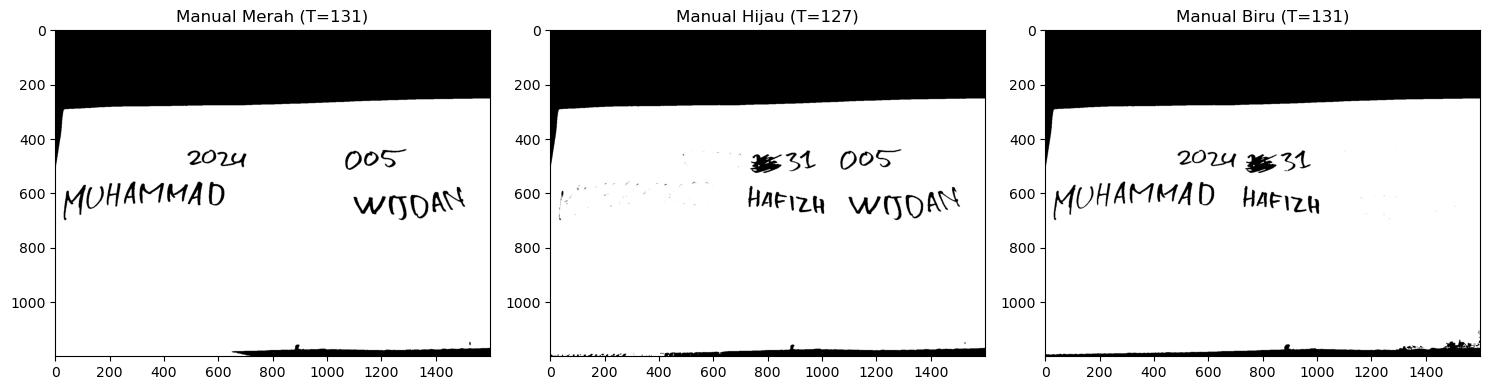

In [6]:

#Thresholding METODE MATEMATIS (Fmin + Fmax) / 2


# 1. Mencari Fmin dan Fmax
fmin_R, fmax_R = np.min(R), np.max(R)
fmin_G, fmax_G = np.min(G), np.max(G)
fmin_B, fmax_B = np.min(B), np.max(B)

# 2. Menghitung (Fmin + Fmax) / 2
T_mid_R = int((int(fmin_R) + int(fmax_R)) / 2)
T_mid_G = int((int(fmin_G) + int(fmax_G)) / 2)
T_mid_B = int((int(fmin_B) + int(fmax_B)) / 2)

# 3. Operasi Logika Biner Manual dengan FOR LOOP dan IF-ELSE
# Kita buat matriks kosong (berisi nol/hitam) terlebih dahulu
thresh_R_mid = np.zeros_like(R, dtype=np.uint8)
thresh_G_mid = np.zeros_like(G, dtype=np.uint8)
thresh_B_mid = np.zeros_like(B, dtype=np.uint8)

# Mengambil ukuran baris (tinggi) dan kolom (lebar) gambar
baris, kolom = R.shape

print("Sedang memproses piksel dengan IF-ELSE (mungkin butuh beberapa detik)...")

# Looping mengecek setiap piksel satu per satu
# PERUBAHAN: Menyesuaikan agar hasilnya hitam putih biasa, bukan di-invers
for i in range(baris):
    for j in range(kolom):
        # Kondisi IF untuk Kanal Merah
        if R[i, j] <= T_mid_R:      # Jika piksel <= Threshold (artinya piksel gelap/tinta)
            thresh_R_mid[i, j] = 0   # Jadikan HITAM (0)
        else:
            thresh_R_mid[i, j] = 255 # Jika lebih terang dari Threshold (kertas), jadikan PUTIH (255)
            
        # Kondisi IF untuk Kanal Hijau
        if G[i, j] <= T_mid_G:
            thresh_G_mid[i, j] = 0
        else:
            thresh_G_mid[i, j] = 255
            
        # Kondisi IF untuk Kanal Biru
        if B[i, j] <= T_mid_B:
            thresh_B_mid[i, j] = 0
        else:
            thresh_B_mid[i, j] = 255

print(f"Selesai! Nilai Threshold (Fmin+Fmax)/2:")
print(f"- Kanal Merah : {T_mid_R}")
print(f"- Kanal Hijau : {T_mid_G}")
print(f"- Kanal Biru  : {T_mid_B}")

# Menampilkan hasil berjejer ke samping (dalam 1 Cell)
fig_mid, axs_mid = plt.subplots(1, 3, figsize=(15, 5))

# PERUBAHAN: Pastikan cmap tetap gray, namun karena isinya dibalik, tampilannya akan putih dengan tulisan hitam/abu
axs_mid[0].imshow(thresh_R_mid, cmap='gray')
axs_mid[0].set_title(f'Manual Merah (T={T_mid_R})')

axs_mid[1].imshow(thresh_G_mid, cmap='gray')
axs_mid[1].set_title(f'Manual Hijau (T={T_mid_G})')

axs_mid[2].imshow(thresh_B_mid, cmap='gray')
axs_mid[2].set_title(f'Manual Biru (T={T_mid_B})')

plt.tight_layout()
plt.show()



In [7]:
print(fmin_R)
print(fmin_G)
print(fmin_B)
print(fmax_R)
print(fmax_G)
print(fmax_B)

7
7
7
255
248
255


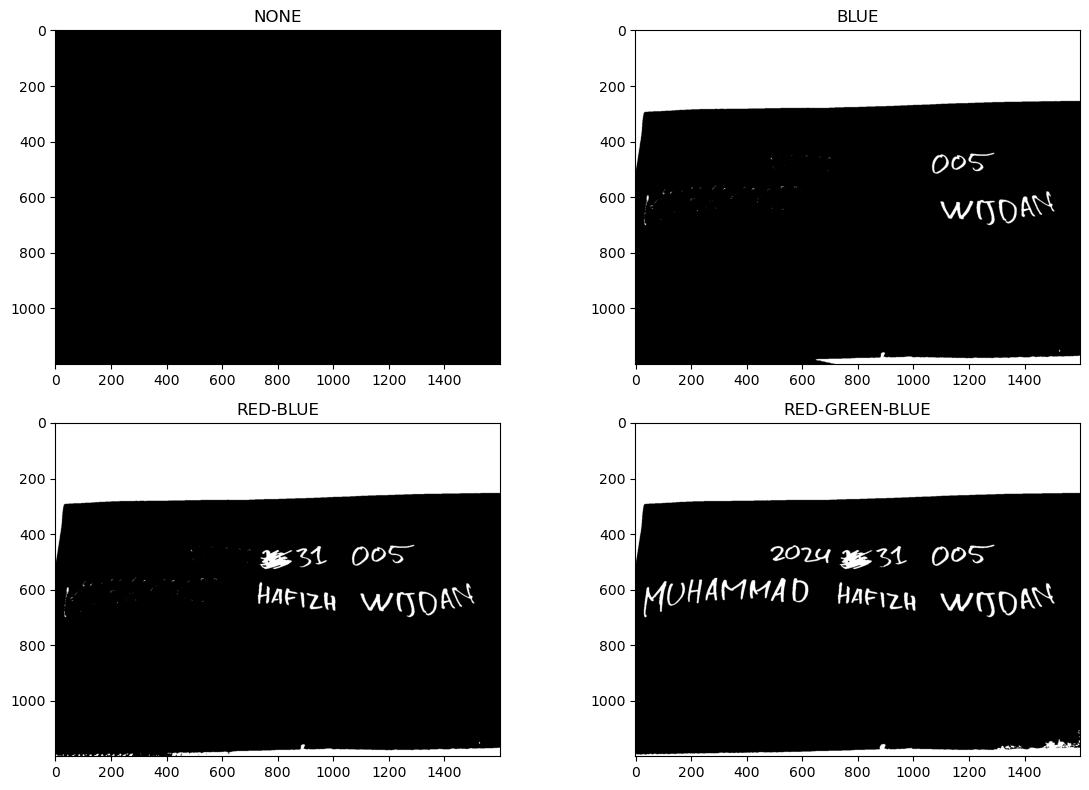

In [8]:
#PENGGABUNGAN (CLIPPING / OPERASI LOGIKA)

# Invers (NOT) hasil thresholding manual agar latar jadi hitam, tulisan jadi putih
inv_R = cv2.bitwise_not(thresh_R_mid)
inv_G = cv2.bitwise_not(thresh_G_mid)
inv_B = cv2.bitwise_not(thresh_B_mid)

# Membuat kanvas kosong dengan ukuran yang sama (untuk NONE)
none_canvas = np.zeros_like(inv_R)

# Logika Penggabungan Warna (Menggunakan gambar yang sudah di-invers)

# 1. BLUE: Warna Biru ada di tulisan yang hilang/pudar di kanal Merah dan kanal Hijau.
blue_only = cv2.bitwise_and(inv_R, inv_G)

# 2. RED-BLUE: Warna Merah dan Biru hilang/pudar di kanal Hijau.
red_blue = inv_G

# 3. RED-GREEN-BLUE: Semua warna.
red_green_blue = cv2.bitwise_or(inv_R, inv_B)

# Menampilkan hasil (seperti Poin F di soal)
fig_clip, axs_clip = plt.subplots(2, 2, figsize=(12, 8))

axs_clip[0, 0].imshow(none_canvas, cmap='gray')
axs_clip[0, 0].set_title('NONE')

axs_clip[0, 1].imshow(blue_only, cmap='gray')
axs_clip[0, 1].set_title('BLUE')

axs_clip[1, 0].imshow(red_blue, cmap='gray')
axs_clip[1, 0].set_title('RED-BLUE')

axs_clip[1, 1].imshow(red_green_blue, cmap='gray')
axs_clip[1, 1].set_title('RED-GREEN-BLUE')

plt.tight_layout()
plt.show()

Sedang memproses Logika Clipping dengan IF-ELSE (mungkin butuh beberapa detik)...


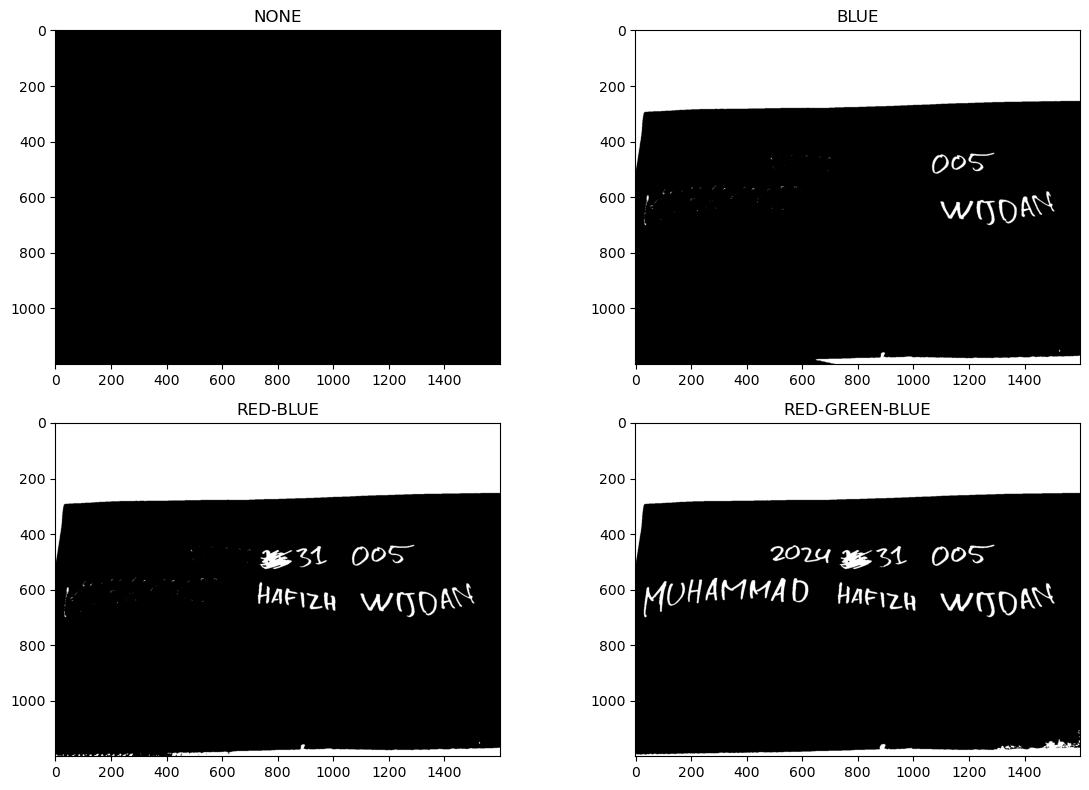

In [9]:
none_canvas = np.zeros_like(R, dtype=np.uint8)
blue_only = np.zeros_like(R, dtype=np.uint8)
red_blue = np.zeros_like(R, dtype=np.uint8)
red_green_blue = np.zeros_like(R, dtype=np.uint8)

print("Sedang memproses Logika Clipping dengan IF-ELSE (mungkin butuh beberapa detik)...")

# Looping mengecek setiap piksel dari hasil Thresholding SEL 4
for i in range(baris):
    for j in range(kolom):
        # 1. BLUE: Warna Biru bernilai Hitam (0) di kanal Merah DAN kanal Hijau.
        # Logika AND: Jika keduanya 0, jadikan Putih (255)
        if thresh_R_mid[i, j] == 0 and thresh_G_mid[i, j] == 0:
            blue_only[i, j] = 255
            
        # 2. RED-BLUE: Tinta Merah dan Biru bernilai Hitam (0) di kanal Hijau.
        if thresh_G_mid[i, j] == 0:
            red_blue[i, j] = 255
            
        # 3. RED-GREEN-BLUE: Semua warna. 
        # Logika OR: Jika gelap di kanal Merah (dapat Hijau, Biru) ATAU gelap di kanal Biru (dapat Merah, Hijau)
        if thresh_R_mid[i, j] == 0 or thresh_B_mid[i, j] == 0:
            red_green_blue[i, j] = 255


# Menampilkan hasil (seperti Poin F di soal)
fig_clip, axs_clip = plt.subplots(2, 2, figsize=(12, 8))

axs_clip[0, 0].imshow(none_canvas, cmap='gray'); axs_clip[0, 0].set_title('NONE')
axs_clip[0, 1].imshow(blue_only, cmap='gray'); axs_clip[0, 1].set_title('BLUE')
axs_clip[1, 0].imshow(red_blue, cmap='gray'); axs_clip[1, 0].set_title('RED-BLUE')
axs_clip[1, 1].imshow(red_green_blue, cmap='gray'); axs_clip[1, 1].set_title('RED-GREEN-BLUE')

plt.tight_layout()
plt.show()

Gambar Awal Deteksi Warna (Kanal R, G, B) berhasil disimpan!


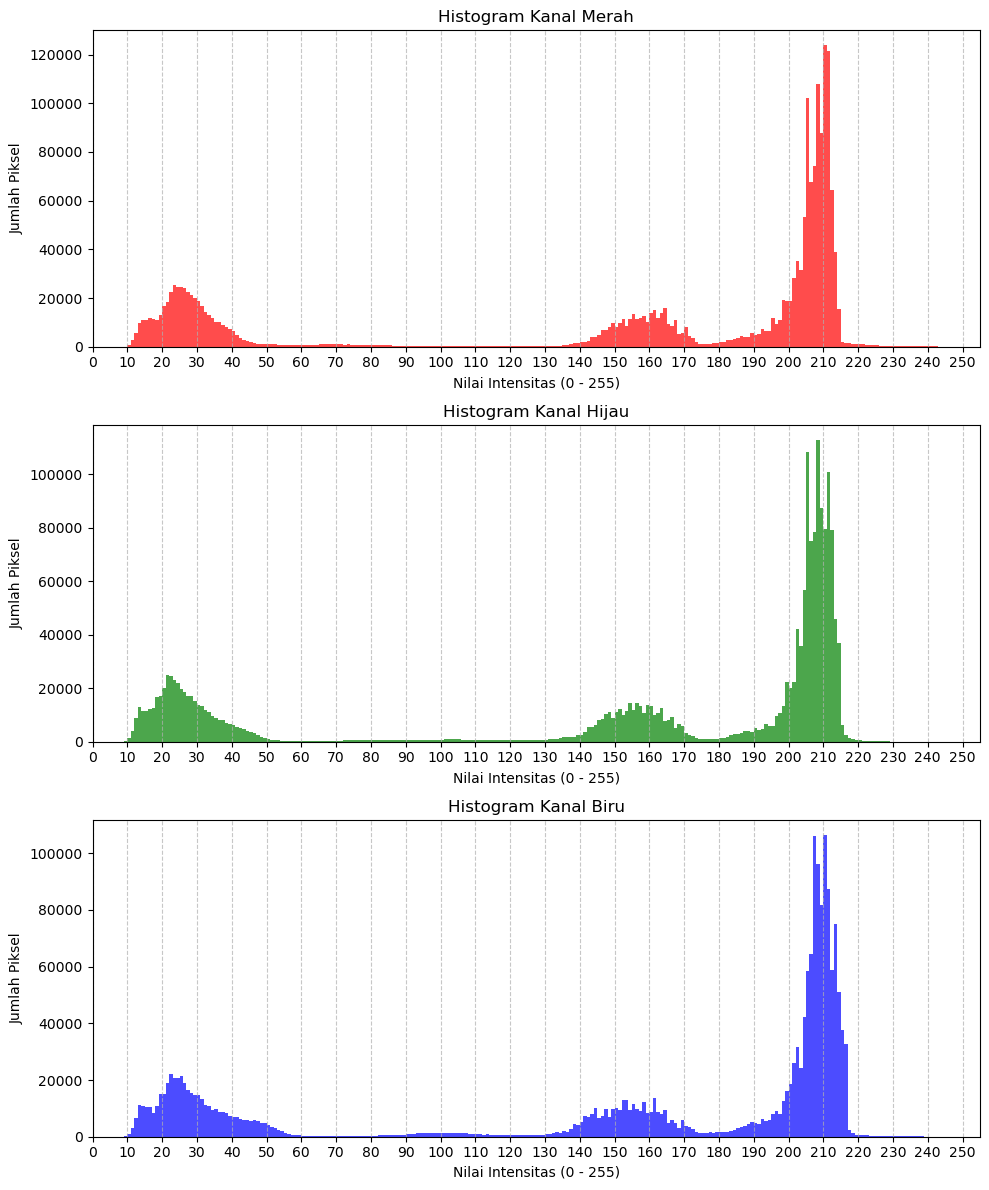

Histogram Awal Deteksi Warna berhasil disimpan!
Gambar hasil operasi logika clipping berhasil disimpan!


In [12]:

# 1. Menyimpan Gambar Awal Deteksi Warna (R, G, B)
cv2.imwrite('kanal_merah.jpg', R)
cv2.imwrite('kanal_hijau.jpg', G)
cv2.imwrite('kanal_biru.jpg', B)
print('Gambar Awal Deteksi Warna (Kanal R, G, B) berhasil disimpan!')

# 2. Menyimpan Histogram Gambar Awal
fig_hist_awal, axs_hist_awal = plt.subplots(3, 1, figsize=(10, 12))
axs_hist_awal[0].hist(R.ravel(), bins=256, range=[0, 256], color='red', alpha=0.7)
axs_hist_awal[0].set_title('Histogram Kanal Merah')
axs_hist_awal[1].hist(G.ravel(), bins=256, range=[0, 256], color='green', alpha=0.7)
axs_hist_awal[1].set_title('Histogram Kanal Hijau')
axs_hist_awal[2].hist(B.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.7)
axs_hist_awal[2].set_title('Histogram Kanal Biru')
for ax in axs_hist_awal:
    ax.set_xlim([0, 255])
    ax.set_xticks(np.arange(0, 260, 10))
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    ax.set_xlabel('Nilai Intensitas (0 - 255)')
    ax.set_ylabel('Jumlah Piksel')
plt.tight_layout()
plt.savefig('histogram_awal.jpg')
plt.show()
print('Histogram Awal Deteksi Warna berhasil disimpan!')

# 3. Menyimpan hasil clipping
cv2.imwrite('blue_only.jpg', blue_only)
cv2.imwrite('red_blue.jpg', red_blue)
cv2.imwrite('red_green_blue.jpg', red_green_blue)
print('Gambar hasil operasi logika clipping berhasil disimpan!')




In [ ]:
# 4. Menyimpan Histogram Masing-Masing Kanal

# Kanal Merah
fig_R = plt.figure(figsize=(8, 6))
plt.hist(R.ravel(), bins=256, range=[0, 256], color='red', alpha=0.7)
plt.title('Histogram Kanal Merah')
plt.xlim([0, 255])
plt.xticks(np.arange(0, 260, 10))
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xlabel('Nilai Intensitas (0 - 255)')
plt.ylabel('Jumlah Piksel')
plt.tight_layout()
plt.savefig('histogram_merah.jpg')
plt.show()

# Kanal Hijau
fig_G = plt.figure(figsize=(8, 6))
plt.hist(G.ravel(), bins=256, range=[0, 256], color='green', alpha=0.7)
plt.title('Histogram Kanal Hijau')
plt.xlim([0, 255])
plt.xticks(np.arange(0, 260, 10))
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xlabel('Nilai Intensitas (0 - 255)')
plt.ylabel('Jumlah Piksel')
plt.tight_layout()
plt.savefig('histogram_hijau.jpg')
plt.show()

# Kanal Biru
fig_B = plt.figure(figsize=(8, 6))
plt.hist(B.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.7)
plt.title('Histogram Kanal Biru')
plt.xlim([0, 255])
plt.xticks(np.arange(0, 260, 10))
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xlabel('Nilai Intensitas (0 - 255)')
plt.ylabel('Jumlah Piksel')
plt.tight_layout()
plt.savefig('histogram_biru.jpg')
plt.show()

print('Setiap histogram (Merah, Hijau, Biru) berhasil disimpan secara individual!')